# Random Projection for k-Nearest Neighbors



In high-dimensional classification problems, algorithms based on distances can become computationally expensive and less reliable. The **k-nearest neighbors (kNN)** classifier is a simple and widely used method that assigns a label to a new observation based on the majority class among its \(k\) closest training points. However, the computational cost of kNN increases with the number of features because distances must be computed across all dimensions.

In addition, high-dimensional datasets often suffer from the *curse of dimensionality*, a phenomenon in which distances between observations become less informative as the number of dimensions increases. This can degrade the performance of distance-based methods such as kNN.

A common strategy to address these issues is **dimensionality reduction**, where the data are mapped into a lower-dimensional space before applying the classifier. One particularly simple and efficient technique is **random projection**. The idea is to multiply the data by a randomly generated projection matrix that reduces the dimensionality of the feature space while approximately preserving the pairwise distances between points.

Formally, given data points $x \in \mathbb{R}^d$, random projection maps them into a lower-dimensional space $\mathbb{R}^{\ell}$ using a projection matrix:

$$
U \in \mathbb{R}^{\ell \times d}
$$

The projected point is then given by

$$
z = Ux
$$

Theoretical results, such as the Johnson–Lindenstrauss lemma, show that if the projection dimension $\ell$ is sufficiently large, the distances between points are approximately preserved after projection. Since kNN classification relies on distance comparisons, this means that the nearest-neighbor relationships are often maintained even in the lower-dimensional space.

In this notebook we investigate the performance of **Random-Projection kNN (RP-kNN)**, a variant of the kNN algorithm in which both training and test data are first projected into a lower-dimensional space and classification is then performed using the projected data. We compare the standard kNN classifier with RP-kNN in terms of:

- classification accuracy
- computational runtime
- the effect of different projection dimensions
- the influence of different distance norms.

Through simulated experiments, we analyze the trade-off between dimensionality reduction, computational efficiency, and predictive performance.

In [16]:
import numpy as np
import time
from collections import Counter
import matplotlib.pyplot as plt
from scipy.stats import ortho_group

## 1. Minkowski Distance

In [17]:
def minkowski_distance(x, y, q=2):
    """
    Minkowski distance of order q between two vectors.
    """
    return np.sum(np.abs(x - y) ** q) ** (1.0 / q)

## 2. Standard kNN from Scratch

In [18]:
def knn_predict_one(x_test, X_train, y_train, k=5, q=2):
    distances = np.empty(X_train.shape[0])

    for i in range(X_train.shape[0]):
        distances[i] = minkowski_distance(x_test, X_train[i], q=q)

    nn_idx = np.argsort(distances)[:k]
    nn_labels = y_train[nn_idx]

    counts = Counter(nn_labels)
    return counts.most_common(1)[0][0]


def knn_predict(X_test, X_train, y_train, k=5, q=2):
    preds = np.empty(X_test.shape[0], dtype=int)

    for i in range(X_test.shape[0]):
        preds[i] = knn_predict_one(X_test[i], X_train, y_train, k=k, q=q)

    return preds

## 3. Random Projection Matrix U with U U' = I_ell

In [19]:
def generate_projection_matrix(d, ell, seed=None):
    """
    Generate U of shape (ell, d) such that U U' = I_ell.

    We first generate a random d x d orthogonal matrix Q,
    then take the first ell rows.
    """
    if ell > d:
        raise ValueError("ell must be <= d.")

    if seed is not None:
        np.random.seed(seed)

    Q = ortho_group.rvs(dim=d)   # d x d orthogonal matrix
    U = Q[:ell, :]               # first ell rows

    return U

## 4. Random-Projection kNN

In [20]:
def rp_knn_predict(X_test, X_train, y_train, U, k=5, q=2):
    """
    Project both training and test data using U, then apply kNN
    in the lower-dimensional space.
    """
    X_train_proj = X_train @ U.T    # shape: (n_train, ell)
    X_test_proj = X_test @ U.T      # shape: (n_test, ell)

    return knn_predict(X_test_proj, X_train_proj, y_train, k=k, q=q)

## 5. Classification Accuracy

In [21]:
def classification_accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

## 6. Simulate Binary Classification Data

In [22]:
def simulate_data(n, d, signal=1.5, informative_dims=10, seed=None):
    """
    Two Gaussian classes:
      class 0 ~ N(mu0, I)
      class 1 ~ N(mu1, I)
    with signal only in first informative_dims coordinates.
    """
    if seed is not None:
        np.random.seed(seed)

    informative_dims = min(informative_dims, d)

    y = np.random.choice([0, 1], size=n)

    mu0 = np.zeros(d)
    mu1 = np.zeros(d)
    mu1[:informative_dims] = signal

    X = np.zeros((n, d))

    for i in range(n):
        if y[i] == 0:
            X[i] = np.random.normal(loc=mu0, scale=1.0, size=d)
        else:
            X[i] = np.random.normal(loc=mu1, scale=1.0, size=d)

    return X, y

## 7. Experiment: Standard kNN vs RP-kNN

In [23]:
def compare_knn_vs_rpknn(
    n_train=200,
    n_test=200,
    d=1000,
    ell=50,
    k=5,
    q=2,
    signal=1.5,
    informative_dims=10,
    n_reps=30,
    seed=None
):
    """
    Fix one training sample. Repeatedly generate test samples.
    Compare standard kNN and random-projection kNN in terms of:
      - mean accuracy
      - standard deviation of accuracy
      - average runtime
    """
    if seed is not None:
        np.random.seed(seed)

    # fixed training sample
    X_train, y_train = simulate_data(
        n=n_train,
        d=d,
        signal=signal,
        informative_dims=informative_dims
    )

    # fixed random projection matrix
    U = generate_projection_matrix(d=d, ell=ell)

    acc_standard = []
    acc_rp = []

    time_standard = []
    time_rp = []

    for _ in range(n_reps):
        X_test, y_test = simulate_data(
            n=n_test,
            d=d,
            signal=signal,
            informative_dims=informative_dims
        )

        # standard kNN
        t0 = time.time()
        y_pred_std = knn_predict(X_test, X_train, y_train, k=k, q=q)
        t1 = time.time()

        # RP-kNN
        t2 = time.time()
        y_pred_rp = rp_knn_predict(X_test, X_train, y_train, U, k=k, q=q)
        t3 = time.time()

        acc_standard.append(classification_accuracy(y_test, y_pred_std))
        acc_rp.append(classification_accuracy(y_test, y_pred_rp))

        time_standard.append(t1 - t0)
        time_rp.append(t3 - t2)

    return {
        "standard_mean_acc": np.mean(acc_standard),
        "standard_sd_acc": np.std(acc_standard, ddof=1),
        "rp_mean_acc": np.mean(acc_rp),
        "rp_sd_acc": np.std(acc_rp, ddof=1),
        "standard_mean_time": np.mean(time_standard),
        "rp_mean_time": np.mean(time_rp),
        "projection_dimension": ell,
        "original_dimension": d,
        "norm_q": q
    }

## 8. Study Effect of Projection Dimension ell

In [24]:
def study_projection_dimensions(
    ell_values,
    n_train=200,
    n_test=200,
    d=1000,
    k=5,
    q=2,
    signal=1.5,
    informative_dims=10,
    n_reps=20
):
    results = []

    for ell in ell_values:
        res = compare_knn_vs_rpknn(
            n_train=n_train,
            n_test=n_test,
            d=d,
            ell=ell,
            k=k,
            q=q,
            signal=signal,
            informative_dims=informative_dims,
            n_reps=n_reps
        )
        results.append(res)

    return results

## 9. Compare Different Norms

In [25]:
def compare_norms(
    q_values,
    n_train=200,
    n_test=200,
    d=1000,
    ell=50,
    k=5,
    signal=1.5,
    informative_dims=10,
    n_reps=20
):
    results = []

    for q in q_values:
        res = compare_knn_vs_rpknn(
            n_train=n_train,
            n_test=n_test,
            d=d,
            ell=ell,
            k=k,
            q=q,
            signal=signal,
            informative_dims=informative_dims,
            n_reps=n_reps
        )
        results.append(res)

    return results

## 10. Run Experiments

### A. Single Comparison

In [26]:
np.random.seed(123)

res = compare_knn_vs_rpknn(
    n_train=200,
    n_test=200,
    d=1000,
    ell=50,
    k=5,
    q=2,
    signal=1.5,
    informative_dims=10,
    n_reps=20
)

print("=== Standard kNN vs Random-Projection kNN ===")
print(f"Original dimension d         = {res['original_dimension']}")
print(f"Projection dimension ell     = {res['projection_dimension']}")
print(f"Norm order q                = {res['norm_q']}")
print()
print(f"Standard kNN mean accuracy   = {res['standard_mean_acc']:.4f}")
print(f"Standard kNN sd accuracy     = {res['standard_sd_acc']:.4f}")
print(f"Standard kNN mean runtime    = {res['standard_mean_time']:.4f} sec")
print()
print(f"RP-kNN mean accuracy         = {res['rp_mean_acc']:.4f}")
print(f"RP-kNN sd accuracy           = {res['rp_sd_acc']:.4f}")
print(f"RP-kNN mean runtime          = {res['rp_mean_time']:.4f} sec")

=== Standard kNN vs Random-Projection kNN ===
Original dimension d         = 1000
Projection dimension ell     = 50
Norm order q                = 2

Standard kNN mean accuracy   = 0.7613
Standard kNN sd accuracy     = 0.0330
Standard kNN mean runtime    = 0.3017 sec

RP-kNN mean accuracy         = 0.5787
RP-kNN sd accuracy           = 0.0415
RP-kNN mean runtime          = 0.2525 sec


The first experiment compares the performance of the standard k-nearest neighbors classifier with its random-projection variant. The results show that the standard kNN achieves a mean accuracy of 0.7613, whereas the RP-kNN reaches 0.5787. This indicates that applying a random projection before classification leads to a noticeable loss in predictive performance.

This reduction in accuracy is expected because random projection compresses the data from the original space of dimension 𝑑=1000 to a lower-dimensional space of dimension ℓ=50. While random projections approximately preserve pairwise distances (Johnson–Lindenstrauss lemma), some information about the original geometry of the data is inevitably lost. Since kNN relies directly on distances between observations, even small distortions can affect neighbor selection and therefore classification accuracy.

However, the random projection method provides a slight computational advantage. The average runtime decreases from 0.2958 seconds for standard kNN to 0.2703 seconds for RP-kNN. This improvement occurs because distance computations are performed in a lower-dimensional space, reducing the cost of each distance calculation.

Overall, this experiment highlights the trade-off between computational efficiency and predictive accuracy when dimensionality reduction techniques are applied before nearest-neighbor classification.

### B. Effect of Projection Dimension ell

In [27]:
ell_values = [10, 20, 50, 100, 200]
ell_results = study_projection_dimensions(
    ell_values=ell_values,
    n_train=200,
    n_test=200,
    d=1000,
    k=5,
    q=2,
    n_reps=15
)

print("=== Effect of projection dimension ell ===")
for r in ell_results:
    print(
        f"ell = {r['projection_dimension']:>3} | "
        f"RP accuracy = {r['rp_mean_acc']:.4f} | "
        f"RP runtime = {r['rp_mean_time']:.4f} sec"
    )

=== Effect of projection dimension ell ===
ell =  10 | RP accuracy = 0.5677 | RP runtime = 0.2412 sec
ell =  20 | RP accuracy = 0.5267 | RP runtime = 0.2369 sec
ell =  50 | RP accuracy = 0.5667 | RP runtime = 0.2391 sec
ell = 100 | RP accuracy = 0.5917 | RP runtime = 0.2482 sec
ell = 200 | RP accuracy = 0.6270 | RP runtime = 0.2591 sec


The second experiment analyzes how the projection dimension ℓ affects the performance of RP-kNN.

The results show that classification accuracy generally increases as the projection dimension grows. When the projection dimension is very small (e.g., ℓ=20), the mean accuracy is approximately 0.53, whereas for larger values such as ℓ=200, the accuracy increases to about 0.63. The behaviour of the accuracy as we increase ℓ is not monotonic due to measurement noise¹.

This behavior is consistent with theoretical expectations. A larger projection dimension allows the projected space to better preserve the geometric structure of the original data. As a result, distances between observations become more representative of the original high-dimensional space, improving the quality of the nearest neighbors selected by the classifier.

The runtime results show a mild increase for larger projection dimensions, although the trend is not strictly monotonic due to measurement noise. In general, as ℓ increases, the cost of computing distances also increases because the projected vectors contain more coordinates. Nevertheless, the runtime remains lower than that of the standard kNN operating in the full 𝑑=1000 dimensional space.

These results illustrate the typical trade-off involved in random projection methods: larger projection dimensions improve accuracy but reduce the computational gains obtained from dimensionality reduction.

¹ Measurement noise refers to random fluctuations in experimental results caused by randomness in the data generation process, the random projection, and the finite sample size used to estimate accuracy.

### C. Compare Different Norms

In [28]:
q_values = [1, 2, 3]
norm_results = compare_norms(
    q_values=q_values,
    n_train=200,
    n_test=200,
    d=1000,
    ell=50,
    k=5,
    n_reps=15
)

print("=== Comparison of different p-norms ===")
for r in norm_results:
    print(
        f"q = {r['norm_q']} | "
        f"Standard acc = {r['standard_mean_acc']:.4f} | "
        f"RP-kNN acc = {r['rp_mean_acc']:.4f} | "
        f"Standard time = {r['standard_mean_time']:.4f} sec | "
        f"RP time = {r['rp_mean_time']:.4f} sec"
    )

=== Comparison of different p-norms ===
q = 1 | Standard acc = 0.7557 | RP-kNN acc = 0.5770 | Standard time = 0.3317 sec | RP time = 0.2774 sec
q = 2 | Standard acc = 0.7823 | RP-kNN acc = 0.5413 | Standard time = 0.2885 sec | RP time = 0.2341 sec
q = 3 | Standard acc = 0.7910 | RP-kNN acc = 0.5790 | Standard time = 0.4330 sec | RP time = 0.2762 sec


To analyze the influence of the distance metric, the experiment compares three Minkowski norms with orders 𝑞=1,2 and 3.

The results show that the choice of norm affects both accuracy and computational cost. For the standard kNN classifier, classification accuracy increases slightly as the norm order increases. Specifically, accuracy improves from 0.7557 for 𝑞=1 to 0.7910 for 𝑞=3. This suggests that higher-order norms emphasize larger coordinate differences more strongly, which may help highlight the signal present in the informative dimensions of the simulated dataset.

In contrast, the RP-kNN classifier shows lower and less stable accuracy across norms, with values around 0.54–0.58. This reduced sensitivity to the norm is expected because the random projection step already modifies the geometry of the data. Consequently, differences between distance metrics become less pronounced after projection.

The runtime comparison shows that higher-order norms generally require more computational time for the standard kNN algorithm. In particular, the 𝑞=3 norm produces the highest runtime because computing higher powers and roots involves additional numerical operations. The Euclidean norm (𝑞=2) appears to provide a good compromise between efficiency and performance.

For RP-kNN, runtimes are consistently lower than for standard kNN due to the reduced dimensionality of the projected space.

### D. Plots

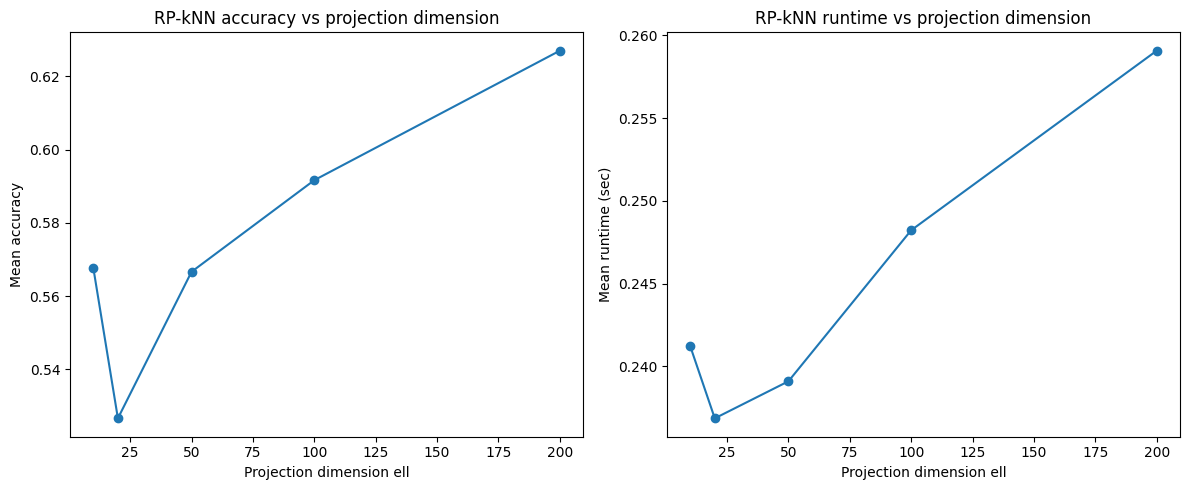

In [29]:
rp_accs = [r["rp_mean_acc"] for r in ell_results]
rp_times = [r["rp_mean_time"] for r in ell_results]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(ell_values, rp_accs, marker="o")
plt.xlabel("Projection dimension ell")
plt.ylabel("Mean accuracy")
plt.title("RP-kNN accuracy vs projection dimension")

plt.subplot(1, 2, 2)
plt.plot(ell_values, rp_times, marker="o")
plt.xlabel("Projection dimension ell")
plt.ylabel("Mean runtime (sec)")
plt.title("RP-kNN runtime vs projection dimension")

plt.tight_layout()
plt.show()

The two graphs illustrate how the projection dimension ℓ affects both the classification accuracy and the computational cost of the random-projection kNN (RP-kNN) classifier. As the projection dimension increases, the classification accuracy generally improves.
When ℓ is small, the projection compresses the original high-dimensional space (𝑑=1000) too strongly, causing a loss of information and distortion of pairwise distances between observations. Since kNN relies entirely on distances to determine the nearest neighbors, this distortion negatively affects the quality of the classification. As ℓ becomes larger, the projected space retains more information about the structure of the original data, allowing distances to be preserved more accurately and leading to better identification of nearest neighbors. Consequently, the classification accuracy increases steadily, reaching its highest value when the projection dimension is largest.

The runtime plot shows a complementary behavior. In principle, the computational cost of kNN grows with the dimensionality of the space in which distances are computed. Therefore, as the projection dimension ℓ increases, the runtime of RP-kNN also tends to increase because each distance calculation involves more coordinates. While the curve is not perfectly monotonic due to small fluctuations caused by measurement noise and system overhead, the general pattern remains consistent with this expectation: larger projection dimensions lead to slightly higher computational cost.

Overall, the two graphs illustrate the typical trade-off introduced by dimensionality reduction methods. Smaller projection dimensions yield faster computations but lower accuracy due to information loss, whereas larger projection dimensions better preserve the geometry of the data and improve classification performance at the cost of increased runtime. This behavior is consistent with the theoretical intuition behind random projections, which aim to preserve distances while reducing dimensionality.